In [5]:
!pip install torchmetrics

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from torchmetrics import Accuracy, JaccardIndex # JaccardIndex é o IoU
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Rodando em: {device}")

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

target_transform = transforms.Compose([
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor(),
    transforms.Lambda(lambda x: x.squeeze(0).long() - 1)
])

print("Baixando dataset...")
full_dataset = datasets.OxfordIIITPet(root='./data', target_types='segmentation', download=True,
                                      transform=transform, target_transform=target_transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
print("Dados prontos!")

Rodando em: cuda
Baixando dataset...
Dados prontos!


In [6]:
class Block(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.relu  = nn.ReLU()
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

    def forward(self, x):
        return self.relu(self.conv2(self.relu(self.conv1(x))))

class MiniUNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.enc1 = Block(3, 32)
        self.pool = nn.MaxPool2d(2)
        self.enc2 = Block(32, 64)

        self.bottleneck = Block(64, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = Block(128, 64)

        self.upconv2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = Block(64, 32)

        self.out = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))

        b = self.bottleneck(self.pool(e2))

        d1 = self.upconv1(b)
        d1 = torch.cat([d1, e2], dim=1)
        d1 = self.dec1(d1)

        d2 = self.upconv2(d1)
        d2 = torch.cat([d2, e1], dim=1)
        d2 = self.dec2(d2)

        return self.out(d2)

model = MiniUNet(num_classes=3).to(device)

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_classes = 3
iou_metric = JaccardIndex(task="multiclass", num_classes=num_classes).to(device)
acc_metric = Accuracy(task="multiclass", num_classes=num_classes).to(device)

epochs = 50

print("Iniciando treinamento...")
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    model.eval()
    iou_metric.reset()
    acc_metric.reset()

    with torch.no_grad():
        for val_images, val_masks in val_loader:
            val_images, val_masks = val_images.to(device), val_masks.to(device)
            val_outputs = model(val_images)

            preds = torch.argmax(val_outputs, dim=1)

            iou_metric.update(preds, val_masks)
            acc_metric.update(preds, val_masks)

    epoch_iou = iou_metric.compute().item()
    epoch_acc = acc_metric.compute().item()

    print(f"Época [{epoch+1}/{epochs}] - Loss Treino: {total_loss/len(train_loader):.4f} | "
          f"Validação -> IoU: {epoch_iou:.4f} - Acurácia: {epoch_acc:.4f}")

print("Treinamento concluído!")

Iniciando treinamento...
Época [1/50] - Loss Treino: 0.8071 | Validação -> IoU: 0.3665 - Acurácia: 0.6881
Época [2/50] - Loss Treino: 0.7026 | Validação -> IoU: 0.4139 - Acurácia: 0.7113
Época [3/50] - Loss Treino: 0.6896 | Validação -> IoU: 0.4212 - Acurácia: 0.7176
Época [4/50] - Loss Treino: 0.6537 | Validação -> IoU: 0.4553 - Acurácia: 0.7245
Época [5/50] - Loss Treino: 0.6159 | Validação -> IoU: 0.5183 - Acurácia: 0.7778
Época [6/50] - Loss Treino: 0.5770 | Validação -> IoU: 0.5402 - Acurácia: 0.7879
Época [7/50] - Loss Treino: 0.5471 | Validação -> IoU: 0.5615 - Acurácia: 0.7991
Época [8/50] - Loss Treino: 0.5266 | Validação -> IoU: 0.5704 - Acurácia: 0.8059
Época [9/50] - Loss Treino: 0.4985 | Validação -> IoU: 0.5733 - Acurácia: 0.8059
Época [10/50] - Loss Treino: 0.4807 | Validação -> IoU: 0.5741 - Acurácia: 0.7990
Época [11/50] - Loss Treino: 0.4722 | Validação -> IoU: 0.5586 - Acurácia: 0.7882
Época [12/50] - Loss Treino: 0.4607 | Validação -> IoU: 0.5603 - Acurácia: 0.8013


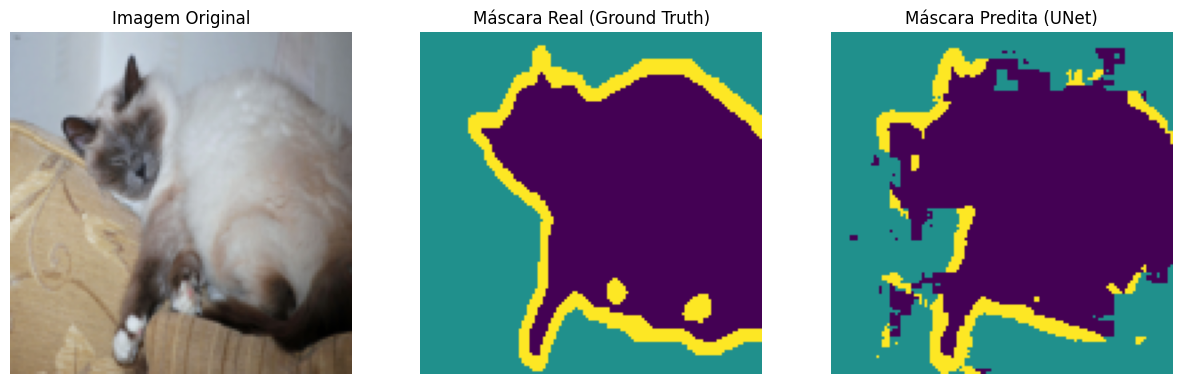

In [8]:
import matplotlib.pyplot as plt

model.eval()

imagens, mascaras_reais = next(iter(val_loader))
imagens, mascaras_reais = imagens.to(device), mascaras_reais.to(device)

with torch.no_grad():
    saidas = model(imagens)

    mascaras_preditas = torch.argmax(saidas, dim=1)

img = imagens[0].cpu().permute(1, 2, 0).numpy()
mascara_real = mascaras_reais[0].cpu().numpy()
mascara_pred = mascaras_preditas[0].cpu().numpy()

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img)
ax[0].set_title("Imagem Original")
ax[0].axis('off')

ax[1].imshow(mascara_real)
ax[1].set_title("Máscara Real (Ground Truth)")
ax[1].axis('off')

ax[2].imshow(mascara_pred)
ax[2].set_title("Máscara Predita (UNet)")
ax[2].axis('off')

plt.show()

In [10]:
!pip install litert-torch

import torch
import litert_torch # Nova biblioteca oficial que substitui a ai_edge_torch

# 1. Definimos um tensor de entrada com as mesmas dimensões usadas no treinamento
# O Android precisará enviar a imagem com essa exata dimensão (1 batch, 3 canais, 128x128 pixels)
tensor_exemplo = torch.randn(1, 3, 128, 128).to(device)

print("Iniciando conversão para TFLite usando LiteRT...")

# 2. Conversão direta do modelo PyTorch mantendo a precisão FP32
modelo_tflite = litert_torch.convert(model.eval(), (tensor_exemplo,))

# 3. Exportando o arquivo físico
nome_arquivo = "unet_segmentacao_fp32.tflite"
modelo_tflite.export(nome_arquivo)

print(f"Sucesso! Arquivo '{nome_arquivo}' gerado na aba de arquivos do Colab.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 575.8/575.8 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.3/419.3 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.6/117.6 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 120.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 30.2 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.15.0
    Uninstalling typing_e

Iniciando conversão para TFLite usando LiteRT...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:01) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

...

(00:05) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)

(00:05) [ DONE] LiteRT-Torch Convert (+00:05)

(00:00) [START] Write Model to unet_segmentacao_fp32.tflite

(00:00) [ DONE] Write Model to unet_segmentacao_fp32.tflite (+00:00)

Sucesso! Arquivo 'unet_segmentacao_fp32.tflite' gerado na aba de arquivos do Colab.
